# VERUS Experimentation #2

**Lisbon, Portugal**

This notebook assesses the spatiotemporal vulnerability of Lisbon with the continuous-occupancy
time-window table and four evaluation times, one per activity regime of the week. It uses the same inputs, grid and scenarios
as the multi-domain Contextual Risk Index analysis (`md-contextual-risk-index`, where the table is
named T1g). The experiments of the
IJDRR article (`default_time_windows.csv`, 250 m grid, Sat 10:20 and Mon 08:40, 12:30 and 17:30) are
kept in the git tag `ijdrr-article`.

| Scenario | Regime | Evaluation time |
|---|---|---|
| s1 | Weekday morning rush | Monday 2023-11-06 08:30 |
| s2 | Weekday late morning | Monday 2023-11-06 11:00 |
| s3 | Weekday night | Monday 2023-11-06 21:00 |
| s4 | Saturday daytime | Saturday 2023-11-11 11:00 |

Scenario labels s1–s4 do not correspond to the article's scenarios 1–4.

Method notes:

- Requires verus >= 1.1.1. Vulnerability is normalized with a zero baseline (`value / max_vulnerability`),
  and time windows are applied to the loaded POTIs on every `run()`, so scenarios evaluated in sequence
  do not inherit each other's `vi` values.
- The continuous-occupancy table (`time_windows_continuous_occupancy.csv`) has exclusive window ends, keeps every category active between its
  peaks, and keeps hospitals and stations at a low level at night. Schools are active only at the gates
  (08:00–10:00 and 16:00–18:00).
- The grid has a 100 m edge length and covers the city boundary in `data/cities/`.
- `max_vulnerability` is the largest raw vulnerability over the four scenarios, so the four layers share
  one scale. It was computed with a first pass at `max_vulnerability = 1.0` and is set statically below.
- Maps use CARTO Voyager tiles, which need the `CARTO_API_KEY` environment variable (without it, the
  tiles carry an "API KEY REQUIRED" watermark).


In [1]:
import os
import warnings

import contextily as ctx
import matplotlib.pyplot as plt
import pandas as pd
import xyzservices
from verus import VERUS
from verus.data import TimeWindowGenerator
from verus.grid import HexagonGridGenerator


def carto_voyager():
    """CARTO Voyager tiles, with the API key read from the CARTO_API_KEY environment variable."""
    provider = ctx.providers.CartoDB.Voyager
    key = os.environ.get("CARTO_API_KEY")
    if not key:
        warnings.warn("CARTO_API_KEY is not set: CARTO tiles will show an 'API KEY REQUIRED' watermark")
        return provider
    return xyzservices.TileProvider({**provider, "url": provider["url"] + "?key=" + key})


CARTO_VOYAGER = carto_voyager()


def plot_vulnerability(zones, title):
    """Smoothed vulnerability on a fixed [0, 1] scale over a CARTO basemap."""
    fig, ax = plt.subplots(figsize=(9, 9))
    zones.to_crs(epsg=3857).plot(
        column="VL_normalized_smoothed",
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        alpha=0.75,
        linewidth=0,
        ax=ax,
        legend=True,
        legend_kwds={"label": "Vulnerability (normalized, smoothed)", "shrink": 0.7},
    )
    ctx.add_basemap(ax, source=CARTO_VOYAGER, crs="EPSG:3857", attribution_size=6)
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

## 1. Data Preparation

To ensure reproducibility, we use a pre-fetched POTI dataset and the continuous-occupancy time-window table.

In [2]:
poti_df = pd.read_csv("../../data/poti/lisbon_dataset_buffered.csv")
time_windows_df = pd.read_csv("../../data/time_windows/time_windows_continuous_occupancy.csv")
scenarios = pd.read_csv("../../data/time_windows/scenarios_activity_regimes.csv")
scenarios

,scenario,regime,evaluation_time
0,s1,Weekday morning rush,2023-11-06 08:30:00
1,s2,Weekday late morning,2023-11-06 11:00:00
2,s3,Weekday night,2023-11-06 21:00:00
3,s4,Saturday daytime,2023-11-11 11:00:00


### 1.1. Generate vulnerability zones

In [3]:
grid_gen = HexagonGridGenerator(region="../../data/cities/lisbon.geojson", edge_length=100)
hex_grid = grid_gen.run()

2026-09-22 14:04:54 [

INFO

] Initialized grid generator for region from file: lisbon.geojson


2026-09-22 14:04:54 [

INFO

...

INFO

] Clipping grid to region boundaries


2026-09-22 14:04:55 [

INFO

] Clipped from 11131 to 6569 hexagons


### 1.2. Initialize vulnerability assessment

In [4]:
# max_vulnerability is the largest raw vulnerability (column `value`) over
# the four scenarios, from a first pass with max_vulnerability = 1.0:
#   s1: 0.00025565961924358673
#   s2: 0.0001851905531384116
#   s3: 5.0889893013050124e-05
#   s4: 0.0002534434902798165
config = {
    "max_vulnerability": {"Lisbon": 0.00025565961924358673},
    "clustering": {
        "optics": {"min_samples": 5, "xi": 0.05, "min_cluster_size": 5},
        "kmeans": {"init": "predefined", "random_state": 42},
    },
}
assessor = VERUS(place_name="Lisbon", config=config)

2026-09-22 14:04:55 [

INFO

] VulnerabilityAssessor initialized for Lisbon using gaussian method


### 1.3. Load data

In [5]:
assessor.load(
    potis_df=poti_df,
    time_windows_df=time_windows_df,
    zones_gdf=hex_grid,
)
# The following warnings are expected since the data was not preprocessed.

2026-09-22 14:04:55 [

WARNING

] POTI DataFrame doesn't have 'vi' column. Using default vi=1.


2026-09-22 14:04:55 [

WARNING

...

INFO

] Loaded 6569 vulnerability zones


2026-09-22 14:04:55 [

INFO

] Loaded 128 time window entries


## 2. Vulnerability Assessment

`VL_normalized` reaches 1 in the scenario with the largest raw vulnerability (s1) and stays below 1 in the others.

### 2.1. s1: Weekday morning rush (Monday 2023-11-06 08:30)

In [6]:
evaluation_time = TimeWindowGenerator.to_unix_epoch("2023-11-06 08:30:00")
results = assessor.run(evaluation_time=evaluation_time)
assert results["vulnerability_zones"]["VL_normalized"].max() <= 1 + 1e-12

2026-09-22 14:04:55 [

INFO

] Applying time windows for evaluation time: 1699259400


2026-09-22 14:04:55 [

INFO

...

INFO

] Smoothed vulnerability statistics:


2026-09-22 14:05:23 [

INFO

] count    6569.000000
mean        0.448395
std         0.145216
min         0.042315
25%         0.356541
50%         0.452779
75%         0.537937
max         1.000000
Name: VL_normalized_smoothed, dtype: float64


**Map of the vulnerability zones**

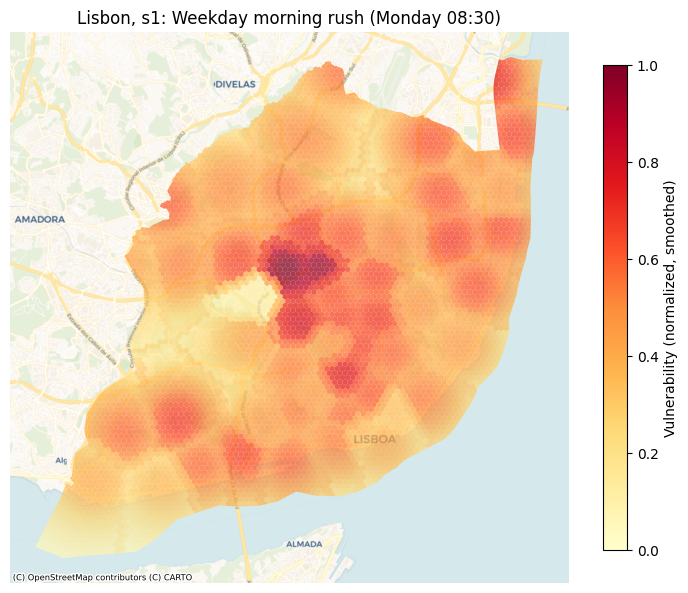

In [7]:
plot_vulnerability(results["vulnerability_zones"], "Lisbon, s1: Weekday morning rush (Monday 08:30)")

### 2.2. s2: Weekday late morning (Monday 2023-11-06 11:00)

In [8]:
evaluation_time = TimeWindowGenerator.to_unix_epoch("2023-11-06 11:00:00")
results = assessor.run(evaluation_time=evaluation_time)
assert results["vulnerability_zones"]["VL_normalized"].max() <= 1 + 1e-12

2026-09-22 14:05:25 [

INFO

] Applying time windows for evaluation time: 1699268400


2026-09-22 14:05:25 [

INFO

...

INFO

] Smoothed vulnerability statistics:


2026-09-22 14:05:53 [

INFO

] count    6569.000000
mean        0.212835
std         0.120229
min         0.029146
25%         0.118598
50%         0.179970
75%         0.282264
max         0.724364
Name: VL_normalized_smoothed, dtype: float64


**Map of the vulnerability zones**

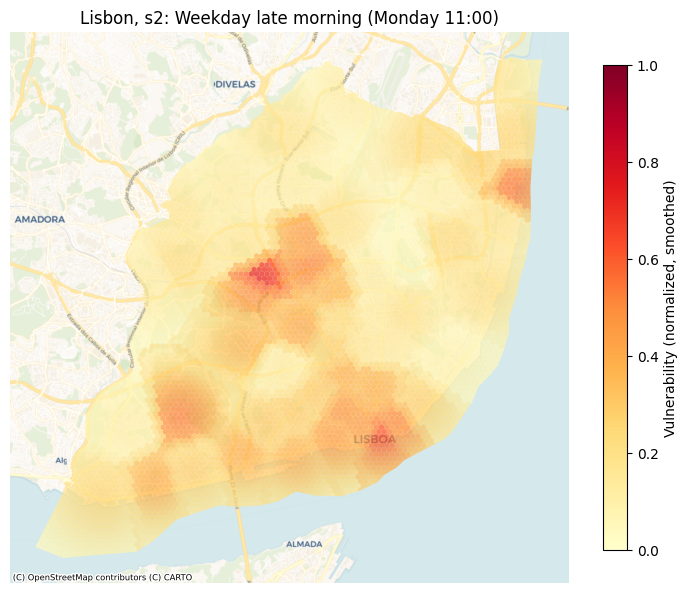

In [9]:
plot_vulnerability(results["vulnerability_zones"], "Lisbon, s2: Weekday late morning (Monday 11:00)")

### 2.3. s3: Weekday night (Monday 2023-11-06 21:00)

In [10]:
evaluation_time = TimeWindowGenerator.to_unix_epoch("2023-11-06 21:00:00")
results = assessor.run(evaluation_time=evaluation_time)
assert results["vulnerability_zones"]["VL_normalized"].max() <= 1 + 1e-12

2026-09-22 14:05:53 [

INFO

] Applying time windows for evaluation time: 1699304400


2026-09-22 14:05:53 [

INFO

...

INFO

] Smoothed vulnerability statistics:


2026-09-22 14:06:20 [

INFO

] count    6569.000000
mean        0.047897
std         0.037458
min         0.000000
25%         0.021443
50%         0.040925
75%         0.067810
max         0.199053
Name: VL_normalized_smoothed, dtype: float64


**Map of the vulnerability zones**

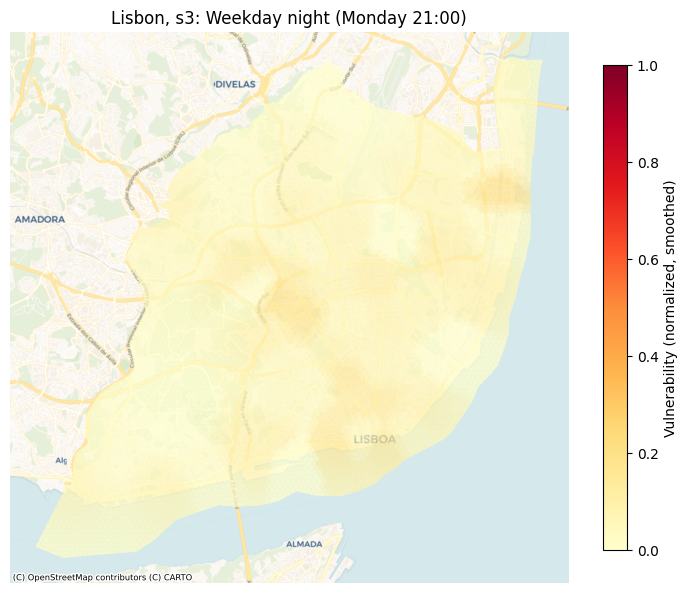

In [11]:
plot_vulnerability(results["vulnerability_zones"], "Lisbon, s3: Weekday night (Monday 21:00)")

### 2.4. s4: Saturday daytime (Saturday 2023-11-11 11:00)

In [12]:
evaluation_time = TimeWindowGenerator.to_unix_epoch("2023-11-11 11:00:00")
results = assessor.run(evaluation_time=evaluation_time)
assert results["vulnerability_zones"]["VL_normalized"].max() <= 1 + 1e-12

2026-09-22 14:06:21 [

INFO

] Applying time windows for evaluation time: 1699700400


2026-09-22 14:06:21 [

INFO

...

INFO

] Smoothed vulnerability statistics:


2026-09-22 14:06:48 [

INFO

] count    6569.000000
mean        0.195383
std         0.147373
min         0.017591
25%         0.090263
50%         0.147904
75%         0.260140
max         0.990430
Name: VL_normalized_smoothed, dtype: float64


**Map of the vulnerability zones**

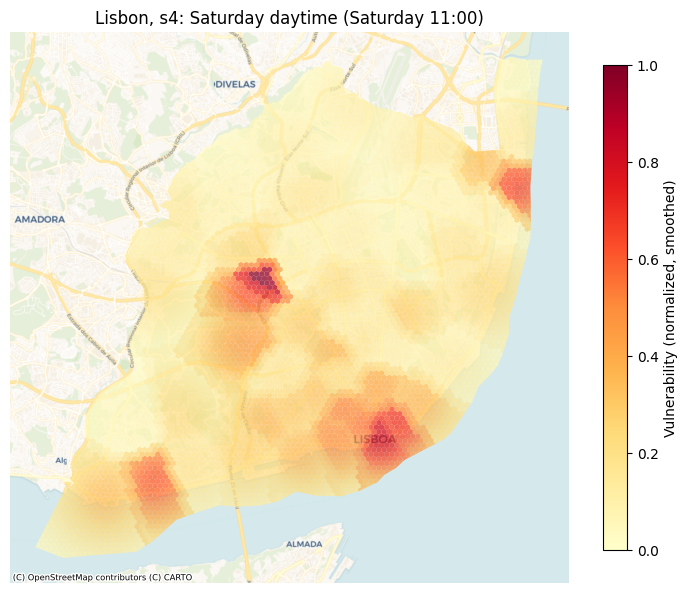

In [13]:
plot_vulnerability(results["vulnerability_zones"], "Lisbon, s4: Saturday daytime (Saturday 11:00)")